# Energy Prediction Master Notebook for Edge Devices

Mục tiêu của notebook:

1. Phân tích toàn diện 2 benchmark dataset thực tế:
   - `253_models_benchmark_rpi5.csv`
   - `360_models_benchmark_jetson.csv`
2. So sánh nhiều họ mô hình để dự đoán năng lượng tiêu thụ trên thiết bị biên.
3. Kiểm chứng công bằng giữa:
   - **approach cũ**: device-specific Extra Trees
   - **approach mới**: multi-device unified models + GNN
4. Chọn **mô hình production tốt nhất**, đồng thời giữ lại toàn bộ quy trình nghiên cứu đầy đủ.


In [1]:
import json
import pickle
import random
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import randint
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, RobustScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "energy_prediction_model_complete.ipynb").exists():
    candidate = NOTEBOOK_DIR / "ml-controller" / "notebooks"
    if candidate.exists():
        NOTEBOOK_DIR = candidate
PROJECT_ROOT = NOTEBOOK_DIR.parent
PYTHON_DIR = PROJECT_ROOT / "python"
if str(PYTHON_DIR) not in sys.path:
    sys.path.insert(0, str(PYTHON_DIR))

from energy_benchmark_workbench import (
    DEFAULT_REPORT_FIGURE_DIR,
    choose_best_model,
    compute_artifact_permutation_importance,
    compute_metrics,
    evaluate_gnn_regressor,
    evaluate_sklearn_models,
    get_feature_columns,
    infer_function_group,
    infer_model_family,
    load_and_prepare_datasets,
    save_best_model,
    set_global_seed,
    split_dataset,
)

SEED = 42
set_global_seed(SEED)
FIGURE_DIR = DEFAULT_REPORT_FIGURE_DIR.parent / "energy_prediction_complete"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook dir:", NOTEBOOK_DIR)
print("Figure dir:", FIGURE_DIR)
print("Artifacts dir:", ARTIFACTS_DIR)


Notebook dir: D:\KLTN\DACN_Energy_consumption\ml-controller\notebooks
Figure dir: D:\KLTN\DACN_Energy_consumption\ml-controller\artifacts\report_figures\energy_prediction_complete
Artifacts dir: D:\KLTN\DACN_Energy_consumption\ml-controller\artifacts


## 1. Tải dữ liệu benchmark và chuẩn hóa

Ở tầng nghiên cứu, ta dùng `load_and_prepare_datasets()` để:

- đọc cả 2 dataset,
- gắn nhãn thiết bị,
- suy luận `model_family` và `function_group`,
- tạo thêm feature hình học đầu vào và các feature tỷ lệ/phối hợp.


In [2]:
rpi_path = PROJECT_ROOT / "data" / "253_models_benchmark_rpi5.csv"
jetson_path = PROJECT_ROOT / "data" / "360_models_benchmark_jetson.csv"

research_df = load_and_prepare_datasets(rpi_path, jetson_path)
research_numeric_features, research_categorical_features, research_feature_columns = get_feature_columns(research_df)

print("Research dataframe shape:", research_df.shape)
print("Numeric features:", len(research_numeric_features))
print("Categorical features:", research_categorical_features)
display(research_df.head())


Research dataframe shape: (613, 45)
Numeric features: 31
Categorical features: ['device_type', 'device_family', 'model_family', 'function_group']


,model,params_m,gflops,gmacs,size_mb,input_size,input_resolution_actual,runs,latency_avg_s,latency_std_s,...,latency_per_gflop,compute_to_memory_ratio,throughput_x_pixels,latency_x_params,latency_x_gflops,complexity_index,batch_run_time_s,is_transformer_like,is_mobile_optimized,device_family
0,convnextv2_atto,3.708,1.095,0.547,14.19,3x224x224,224x224,3,5.537374,0.058573,...,5.056963,0.077167,0.009061,20.532583,6.063425,3.117206,16.612122,0,0,cpu_edge
1,convnextv2_femto,5.233,1.559,0.780,20.01,3x224x224,224x224,3,6.665500,0.069823,...,4.275497,0.077911,0.007528,34.880561,10.391514,5.235463,19.996500,0,0,cpu_edge
2,convnextv2_pico,9.066,2.734,1.367,34.63,3x224x224,224x224,3,9.940316,0.032677,...,3.635814,0.078949,0.005048,90.118905,27.176824,10.870627,29.820948,0,0,cpu_edge
3,deit_small_patch16_224,22.051,8.482,4.241,84.17,3x224x224,224x224,3,15.681934,0.041488,...,1.848849,0.100772,0.003200,345.802327,133.014164,31.370104,47.045802,1,0,cpu_edge
4,deit_tiny_patch16_224,5.717,2.150,1.075,21.86,3x224x224,224x224,3,5.886788,0.067987,...,2.738041,0.098353,0.008523,33.654767,12.656594,6.838936,17.660364,1,0,cpu_edge


## 2. Feature engineering production-grade từ notebook cũ

Để giữ đúng model tốt nhất hiện tại của production, notebook này tái sử dụng chính bộ đặc trưng từ notebook cũ và `EnergyPredictorService`.

Đặc điểm của bộ feature cũ:

- tập trung vào đặc trưng suy diễn liên quan trực tiếp đến chi phí suy luận,
- có `batch_high_power` để tách power profile trên Jetson,
- không dùng categorical encoding để giữ tương thích runtime service.


In [3]:
BASE_FEATURES_OLD = [
    "params_m",
    "gflops",
    "gmacs",
    "size_mb",
    "latency_avg_s",
    "throughput_iter_per_s",
]

FEATURE_COLUMNS_OLD = BASE_FEATURES_OLD + [
    "gflops_per_param",
    "gmacs_per_mb",
    "latency_throughput_ratio",
    "compute_intensity",
    "model_complexity",
    "computational_density",
    "log_params_m",
    "log_gflops",
    "log_size_mb",
    "log_gmacs",
    "log_latency",
    "log_throughput",
    "log_model_complexity",
    "log_compute_intensity",
    "log_params_x_log_latency",
    "log_gflops_x_log_latency",
    "batch_high_power",
]

JETSON_BATCH_THRESHOLD = 10.0

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-9
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)

def mape_eps(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "mae": float(np.mean(np.abs(y_true - y_pred))),
        "rmse": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        "smape": float(smape(y_true, y_pred)),
        "mape_eps": float(mape_eps(y_true, y_pred)),
        "r2_original": float(__import__("sklearn.metrics").metrics.r2_score(y_true, y_pred)),
        "r2_log": float(__import__("sklearn.metrics").metrics.r2_score(np.log1p(y_true), np.log1p(np.clip(y_pred, 0, None)))),
        "median_abs_error": float(np.median(np.abs(y_true - y_pred))),
    }

def add_old_device_features(df: pd.DataFrame, device_key: str) -> pd.DataFrame:
    df = df.copy()
    df["device"] = device_key
    df["gflops_per_param"] = df["gflops"] / (df["params_m"] + 1e-6)
    df["gmacs_per_mb"] = df["gmacs"] / (df["size_mb"] + 1e-6)
    df["latency_throughput_ratio"] = df["latency_avg_s"] * df["throughput_iter_per_s"]
    df["compute_intensity"] = df["gflops"] * df["latency_avg_s"]
    df["model_complexity"] = df["params_m"] * df["gflops"]
    df["computational_density"] = df["gflops"] / (df["size_mb"] + 1e-6)
    df["log_params_m"] = np.log1p(df["params_m"])
    df["log_gflops"] = np.log1p(df["gflops"])
    df["log_size_mb"] = np.log1p(df["size_mb"])
    df["log_gmacs"] = np.log1p(df["gmacs"])
    df["log_latency"] = np.log1p(df["latency_avg_s"])
    df["log_throughput"] = np.log1p(df["throughput_iter_per_s"])
    df["log_model_complexity"] = np.log1p(df["model_complexity"])
    df["log_compute_intensity"] = np.log1p(df["compute_intensity"])
    df["log_params_x_log_latency"] = df["log_params_m"] * df["log_latency"]
    df["log_gflops_x_log_latency"] = df["log_gflops"] * df["log_latency"]
    if "jetson" in device_key:
        power_ratio = df["energy_avg_mwh"] / (df["latency_avg_s"] + 1e-9)
        df["batch_high_power"] = (power_ratio > JETSON_BATCH_THRESHOLD).astype(int)
    else:
        df["batch_high_power"] = 0
    return df

legacy_df = pd.concat(
    [
        add_old_device_features(research_df[research_df["device_type"] == "jetson_nano"], "jetson_nano"),
        add_old_device_features(research_df[research_df["device_type"] == "raspberry_pi5"], "raspberry_pi5"),
    ],
    ignore_index=False,
).sort_index()

print("Legacy/production dataframe shape:", legacy_df.shape)
display(legacy_df[FEATURE_COLUMNS_OLD + ["device_type", "energy_avg_mwh"]].head())


Legacy/production dataframe shape: (613, 62)


,params_m,gflops,gmacs,size_mb,latency_avg_s,throughput_iter_per_s,gflops_per_param,gmacs_per_mb,latency_throughput_ratio,compute_intensity,...,log_gmacs,log_latency,log_throughput,log_model_complexity,log_compute_intensity,log_params_x_log_latency,log_gflops_x_log_latency,batch_high_power,device_type,energy_avg_mwh
0,3.708,1.095,0.547,14.19,5.537374,0.180591,0.295307,0.038548,1.0,6.063425,...,0.436318,1.877536,0.166015,1.621418,1.954930,2.908797,1.388538,0,raspberry_pi5,4.611165
1,5.233,1.559,0.780,20.01,6.665500,0.150026,0.297917,0.038981,1.0,10.391514,...,0.576613,2.036730,0.139785,2.214655,2.432869,3.726926,1.913745,0,raspberry_pi5,5.912482
2,9.066,2.734,1.367,34.63,9.940316,0.100600,0.301566,0.039474,1.0,27.176824,...,0.861623,2.392455,0.095856,3.249849,3.338500,5.524569,3.152011,0,raspberry_pi5,9.444861
3,22.051,8.482,4.241,84.17,15.681934,0.063768,0.384654,0.050386,1.0,133.014164,...,1.656512,2.814326,0.061817,5.236637,4.897945,8.830538,6.330532,0,raspberry_pi5,16.886641
4,5.717,2.150,1.075,21.86,5.886788,0.169872,0.376071,0.049177,1.0,12.656594,...,0.729961,1.929605,0.156894,2.587128,2.614222,3.675206,2.214033,0,raspberry_pi5,5.509666


## 3. EDA tổng quan dữ liệu

Phần này lấy từ notebook mới vì phù hợp cho phân tích và viết paper:

- thống kê theo thiết bị,
- missing values,
- mô tả phân phối biến mục tiêu và các biến cốt lõi.


In [4]:
device_summary = (
    research_df.groupby("device_name")
    .agg(
        samples=("model", "count"),
        energy_mean_mwh=("energy_avg_mwh", "mean"),
        energy_std_mwh=("energy_avg_mwh", "std"),
        latency_mean_s=("latency_avg_s", "mean"),
        params_mean_m=("params_m", "mean"),
        gflops_mean=("gflops", "mean"),
    )
    .round(4)
)

missing_df = research_df.isna().sum().sort_values(ascending=False).rename("missing_count").to_frame()
display(device_summary)
display(missing_df.head(20))
display(research_df[["energy_avg_mwh", "latency_avg_s", "params_m", "gflops", "size_mb"]].describe().round(4))


,samples,energy_mean_mwh,energy_std_mwh,latency_mean_s,params_mean_m,gflops_mean
device_name,,,,,,
Jetson Nano,360,324.1472,887.9852,38.9761,24.9141,7.9137
Raspberry Pi 5,253,44.5617,36.4139,40.7938,12.4052,3.4498


,missing_count
duration_std_s,360
duration_mean_s,360
duration_run3_s,360
duration_run2_s,360
duration_run1_s,360
input_size,0
input_resolution_actual,0
runs,0
model,0
params_m,0


,energy_avg_mwh,latency_avg_s,params_m,gflops,size_mb
count,613.0000,613.0000,613.0000,613.0000,613.0000
mean,208.7555,39.7263,19.7514,6.0713,68.8640
std,694.3120,91.0355,26.5705,8.9624,81.5715
min,2.3914,0.0240,0.0727,0.0040,4.9800
25%,22.2688,0.2961,5.4167,0.8280,21.1300
50%,51.5868,13.3600,10.5897,3.0080,42.0700
75%,128.9329,43.8824,22.0510,7.3600,84.1700
max,11736.4090,1343.1784,138.3660,91.2460,527.8900


## 4. EDA: phân bố theo thiết bị

Mục tiêu:

- xem phân phối năng lượng và độ trễ khác nhau thế nào giữa Raspberry Pi 5 và Jetson Nano,
- quan sát có outlier lớn hay không,
- hỗ trợ diễn giải khi sau này model production tách theo device.


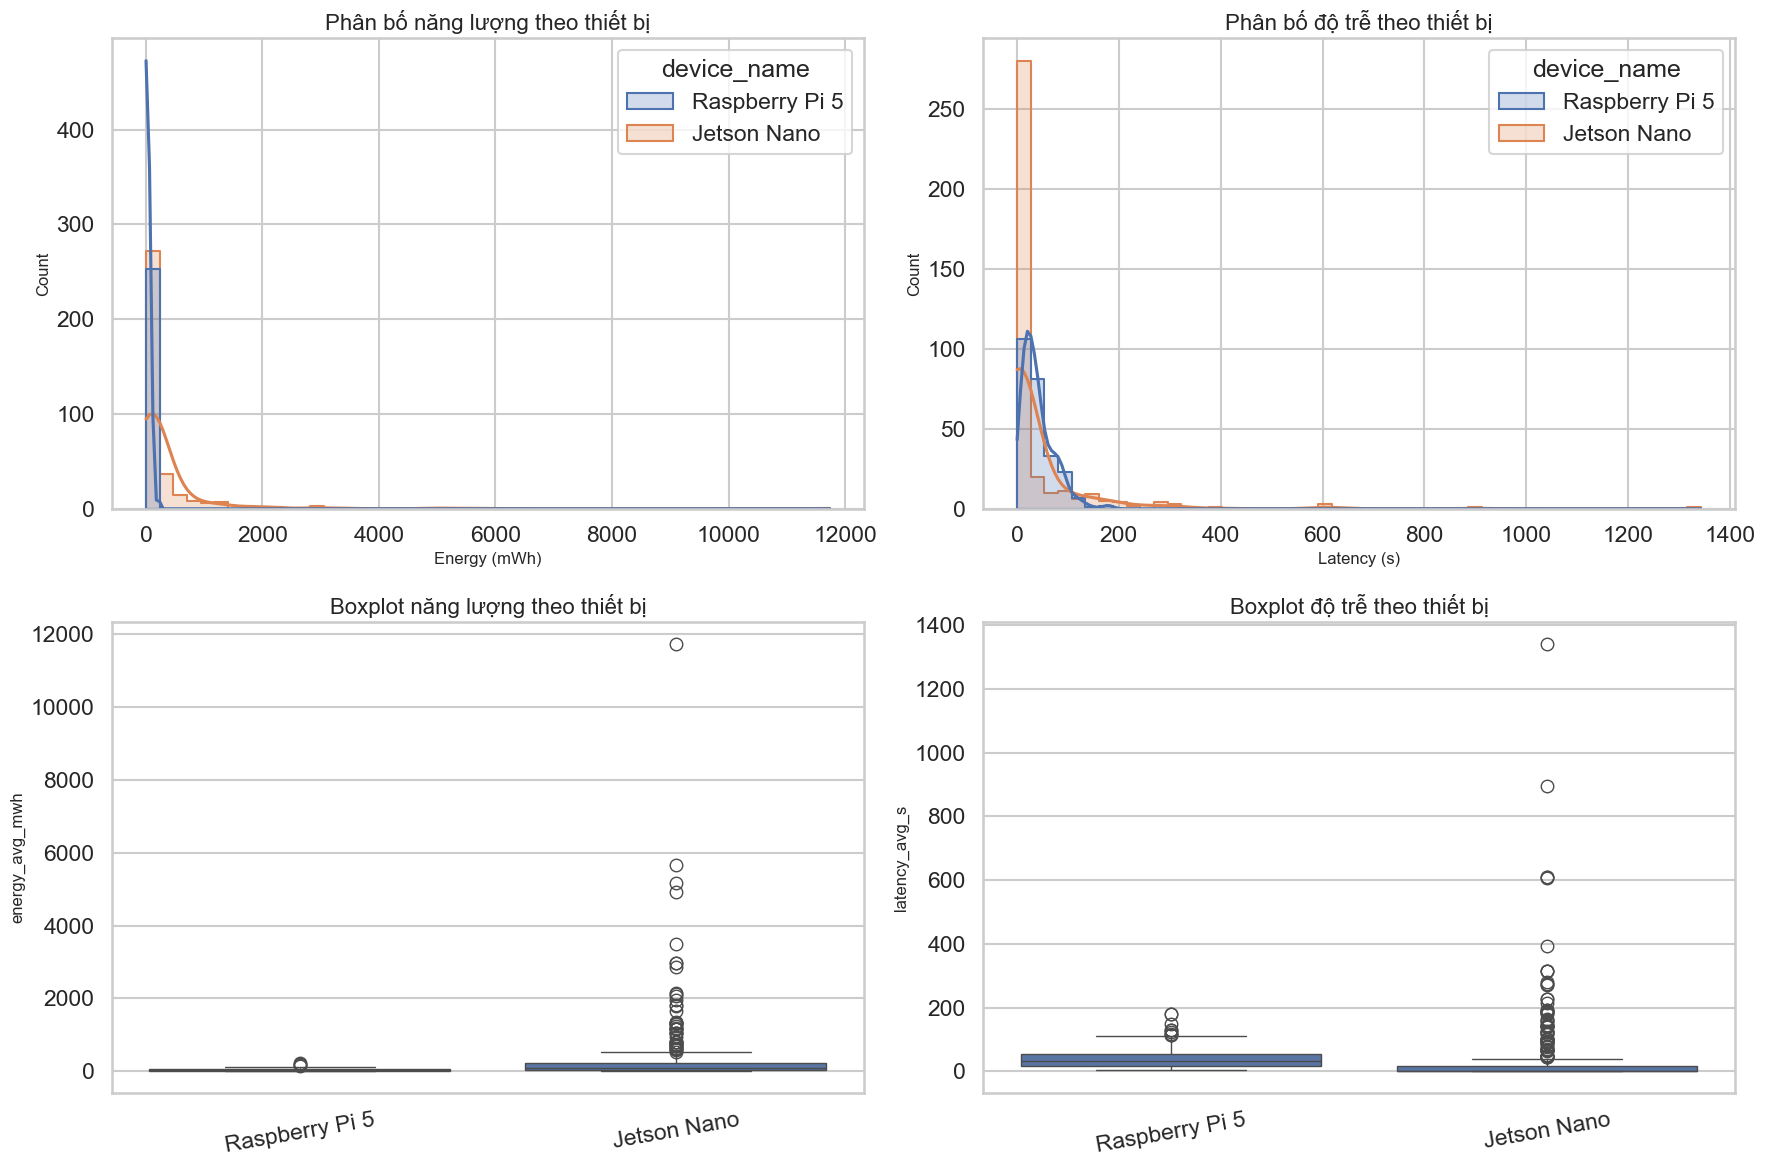

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.histplot(data=research_df, x="energy_avg_mwh", hue="device_name", kde=True, element="step", ax=axes[0, 0])
axes[0, 0].set_title("Phân bố năng lượng theo thiết bị")
axes[0, 0].set_xlabel("Energy (mWh)")

sns.histplot(data=research_df, x="latency_avg_s", hue="device_name", kde=True, element="step", ax=axes[0, 1])
axes[0, 1].set_title("Phân bố độ trễ theo thiết bị")
axes[0, 1].set_xlabel("Latency (s)")

sns.boxplot(data=research_df, x="device_name", y="energy_avg_mwh", ax=axes[1, 0])
axes[1, 0].set_title("Boxplot năng lượng theo thiết bị")
axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", rotation=10)

sns.boxplot(data=research_df, x="device_name", y="latency_avg_s", ax=axes[1, 1])
axes[1, 1].set_title("Boxplot độ trễ theo thiết bị")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_distribution_by_device.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. EDA: phân bố họ mô hình và nhóm chức năng

Đây là phần rất hữu ích cho báo cáo nghiên cứu vì cho thấy:

- dữ liệu tập trung vào họ nào,
- mức cân bằng giữa các kiến trúc,
- sự khác biệt giữa `mobile_edge`, `cnn_backbone`, `vision_transformer`, ...


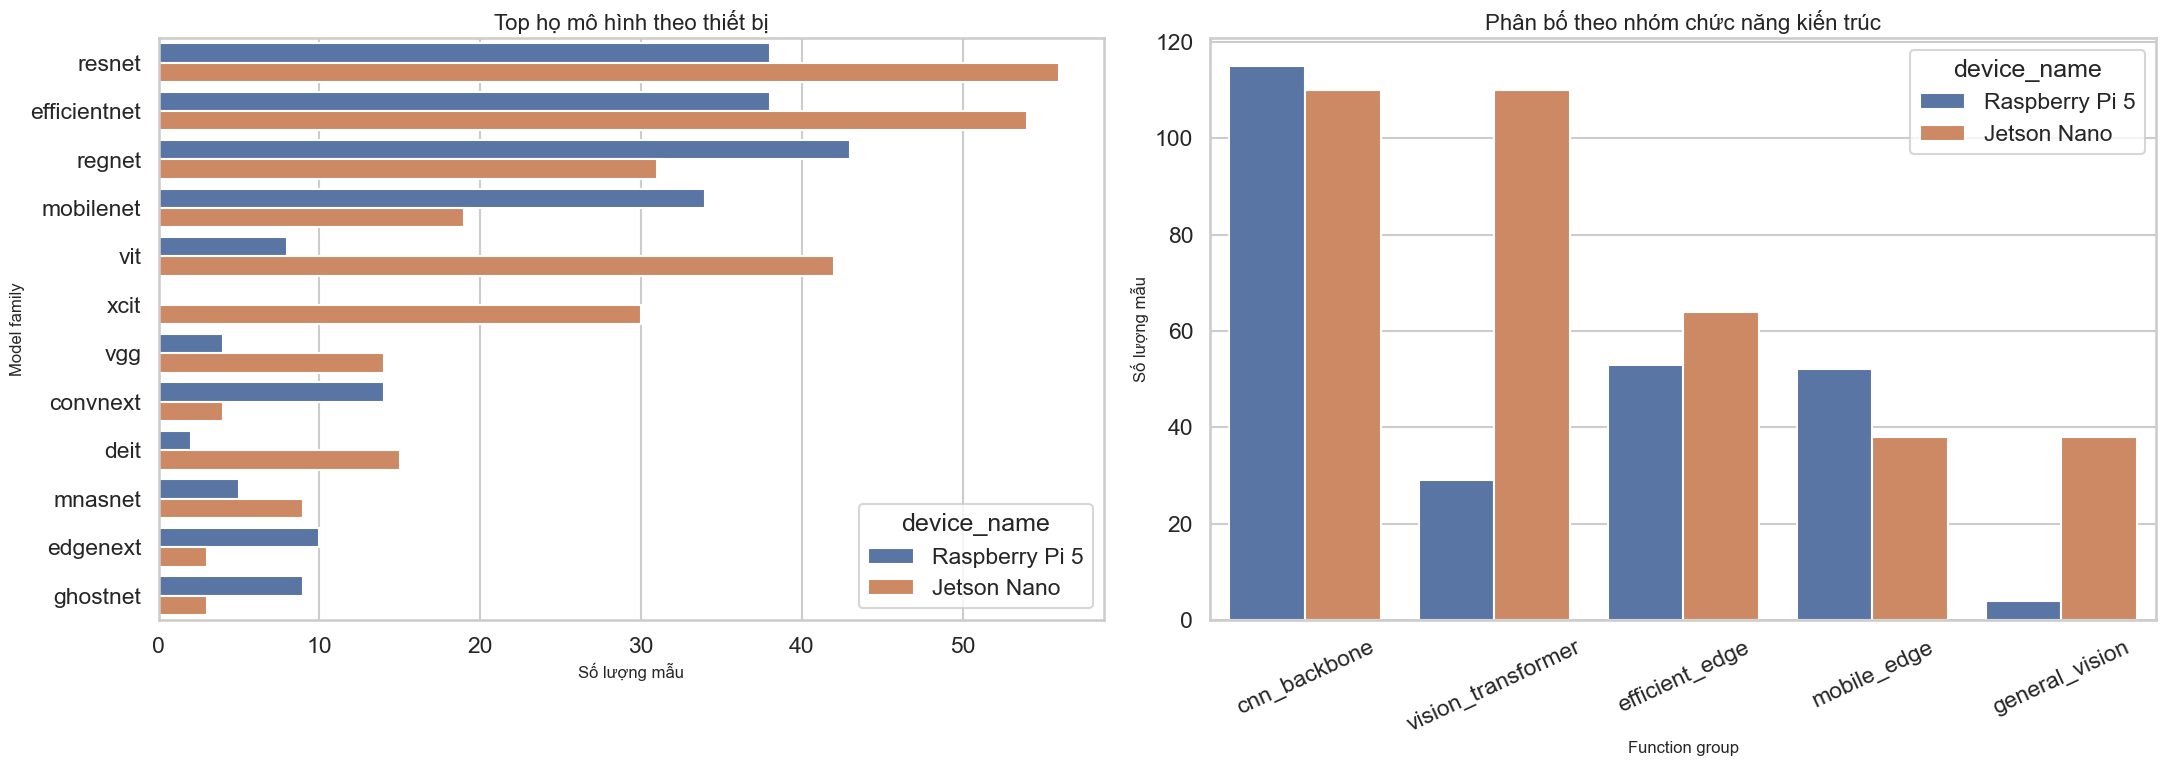

,device_name,function_group,samples
0,Jetson Nano,cnn_backbone,110
4,Jetson Nano,vision_transformer,110
1,Jetson Nano,efficient_edge,64
2,Jetson Nano,general_vision,38
3,Jetson Nano,mobile_edge,38
5,Raspberry Pi 5,cnn_backbone,115
6,Raspberry Pi 5,efficient_edge,53
8,Raspberry Pi 5,mobile_edge,52
9,Raspberry Pi 5,vision_transformer,29
7,Raspberry Pi 5,general_vision,4


In [6]:
top_families = research_df["model_family"].value_counts().head(12).index
family_df = research_df[research_df["model_family"].isin(top_families)].copy()

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.countplot(
    data=family_df,
    y="model_family",
    hue="device_name",
    order=top_families,
    ax=axes[0],
)
axes[0].set_title("Top họ mô hình theo thiết bị")
axes[0].set_xlabel("Số lượng mẫu")
axes[0].set_ylabel("Model family")

sns.countplot(
    data=research_df,
    x="function_group",
    hue="device_name",
    order=research_df["function_group"].value_counts().index,
    ax=axes[1],
)
axes[1].set_title("Phân bố theo nhóm chức năng kiến trúc")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_xlabel("Function group")
axes[1].set_ylabel("Số lượng mẫu")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_family_function_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

display(
    research_df.groupby(["device_name", "function_group"]).size().reset_index(name="samples").sort_values(
        ["device_name", "samples"], ascending=[True, False]
    )
)


## 6. EDA: quan hệ với năng lượng tiêu thụ

Ta trực quan hóa mối quan hệ giữa `energy_avg_mwh` với:

- `latency_avg_s`
- `params_m`
- `gflops`
- `size_mb`


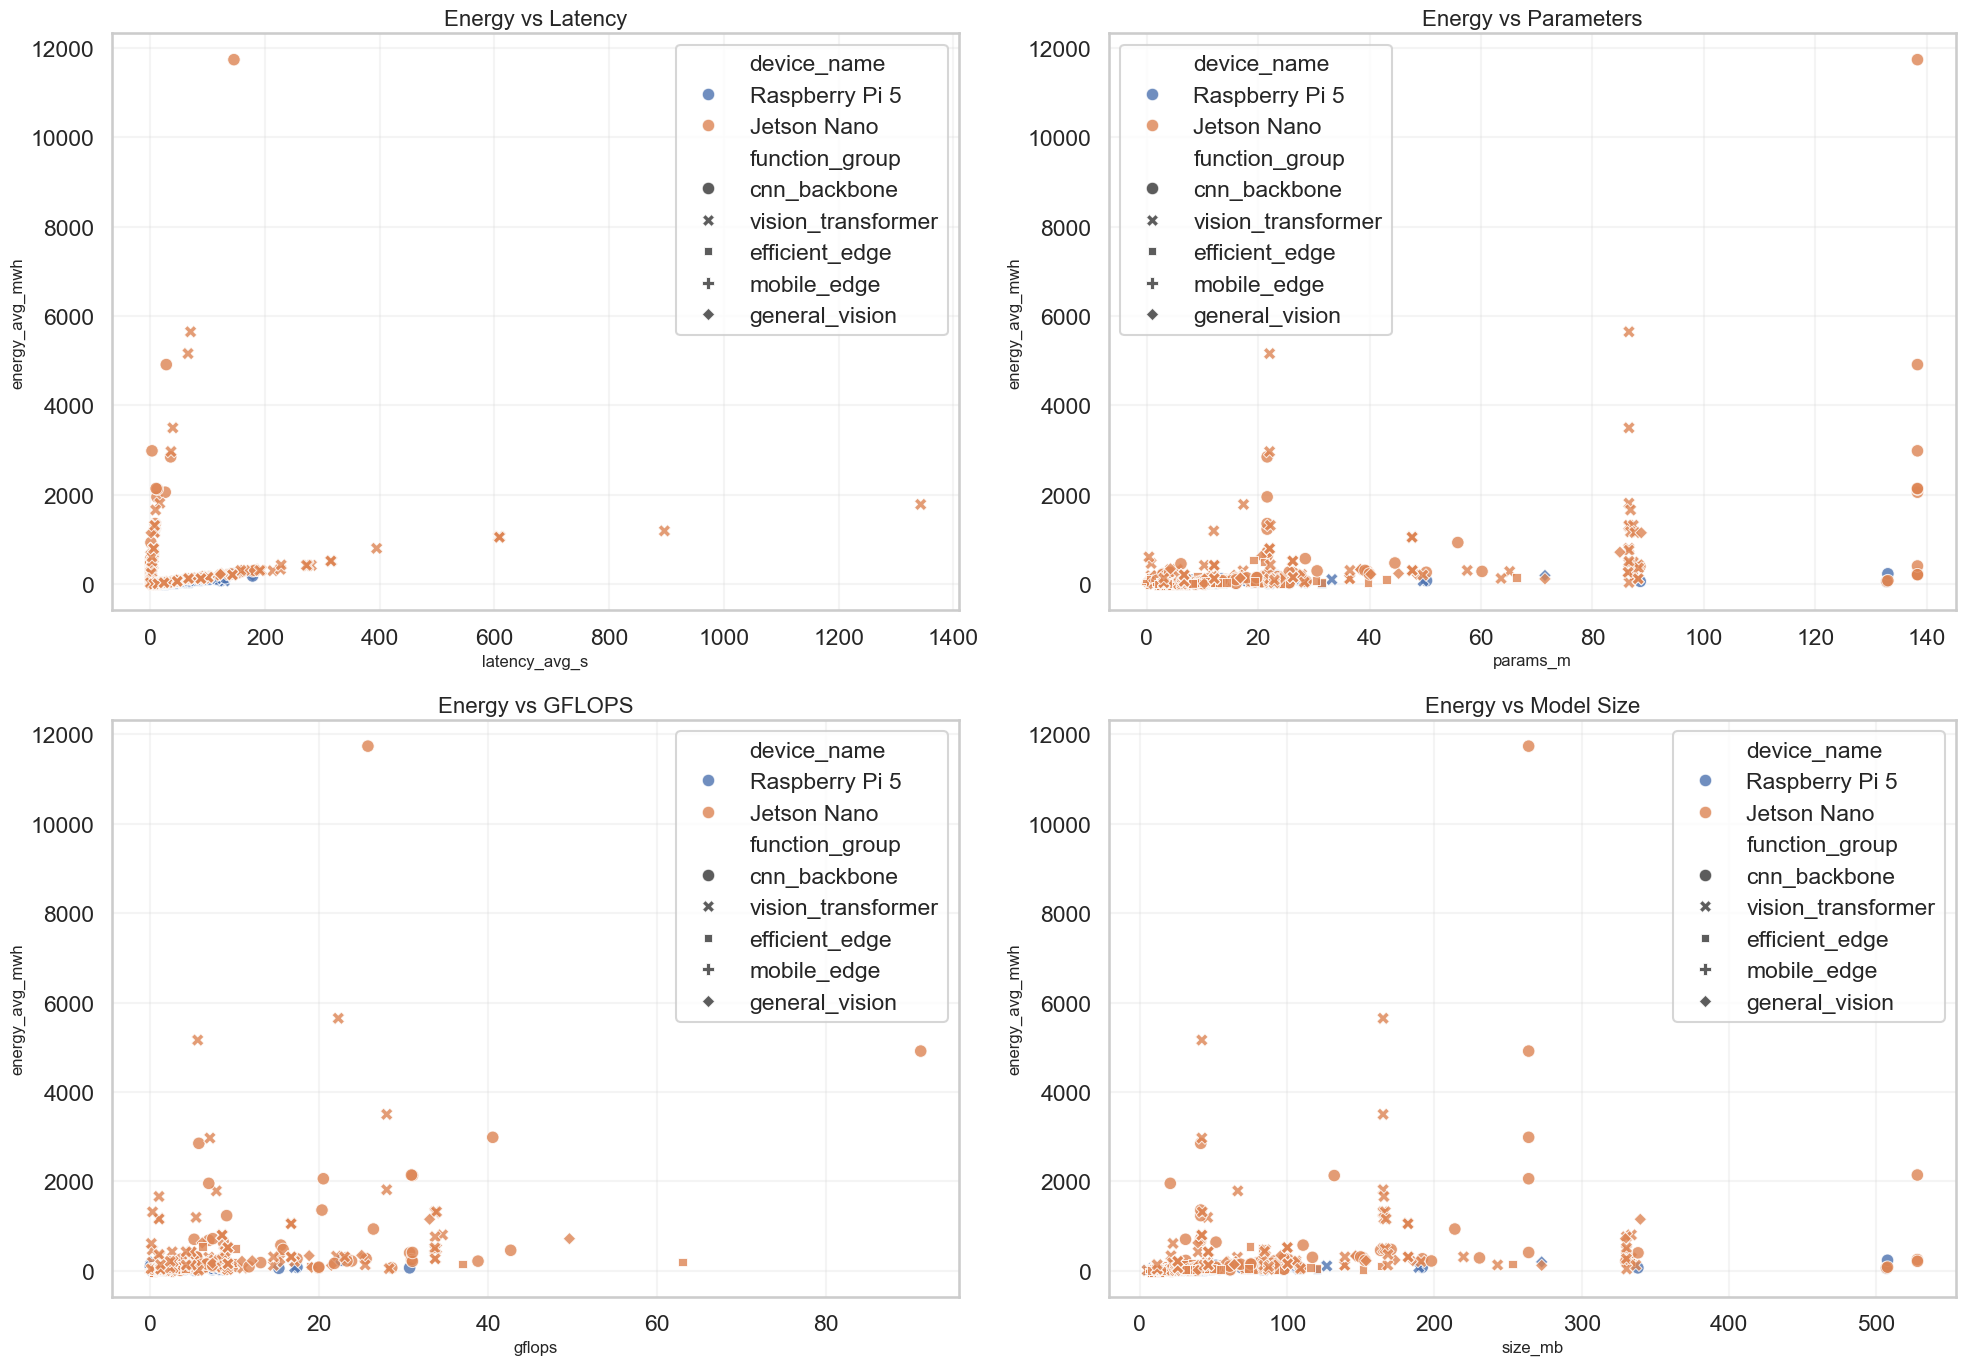

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

sns.scatterplot(data=research_df, x="latency_avg_s", y="energy_avg_mwh", hue="device_name", style="function_group", alpha=0.8, ax=axes[0, 0])
axes[0, 0].set_title("Energy vs Latency")

sns.scatterplot(data=research_df, x="params_m", y="energy_avg_mwh", hue="device_name", style="function_group", alpha=0.8, ax=axes[0, 1])
axes[0, 1].set_title("Energy vs Parameters")

sns.scatterplot(data=research_df, x="gflops", y="energy_avg_mwh", hue="device_name", style="function_group", alpha=0.8, ax=axes[1, 0])
axes[1, 0].set_title("Energy vs GFLOPS")

sns.scatterplot(data=research_df, x="size_mb", y="energy_avg_mwh", hue="device_name", style="function_group", alpha=0.8, ax=axes[1, 1])
axes[1, 1].set_title("Energy vs Model Size")

for ax in axes.flat:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_energy_relationships.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Ma trận tương quan

Giữ tinh thần của notebook cũ, nhưng dùng tập feature giàu hơn của notebook mới để:

- nhìn thấy tương quan giữa năng lượng và các biến lõi,
- xác nhận feature engineering có hợp lý hay không.


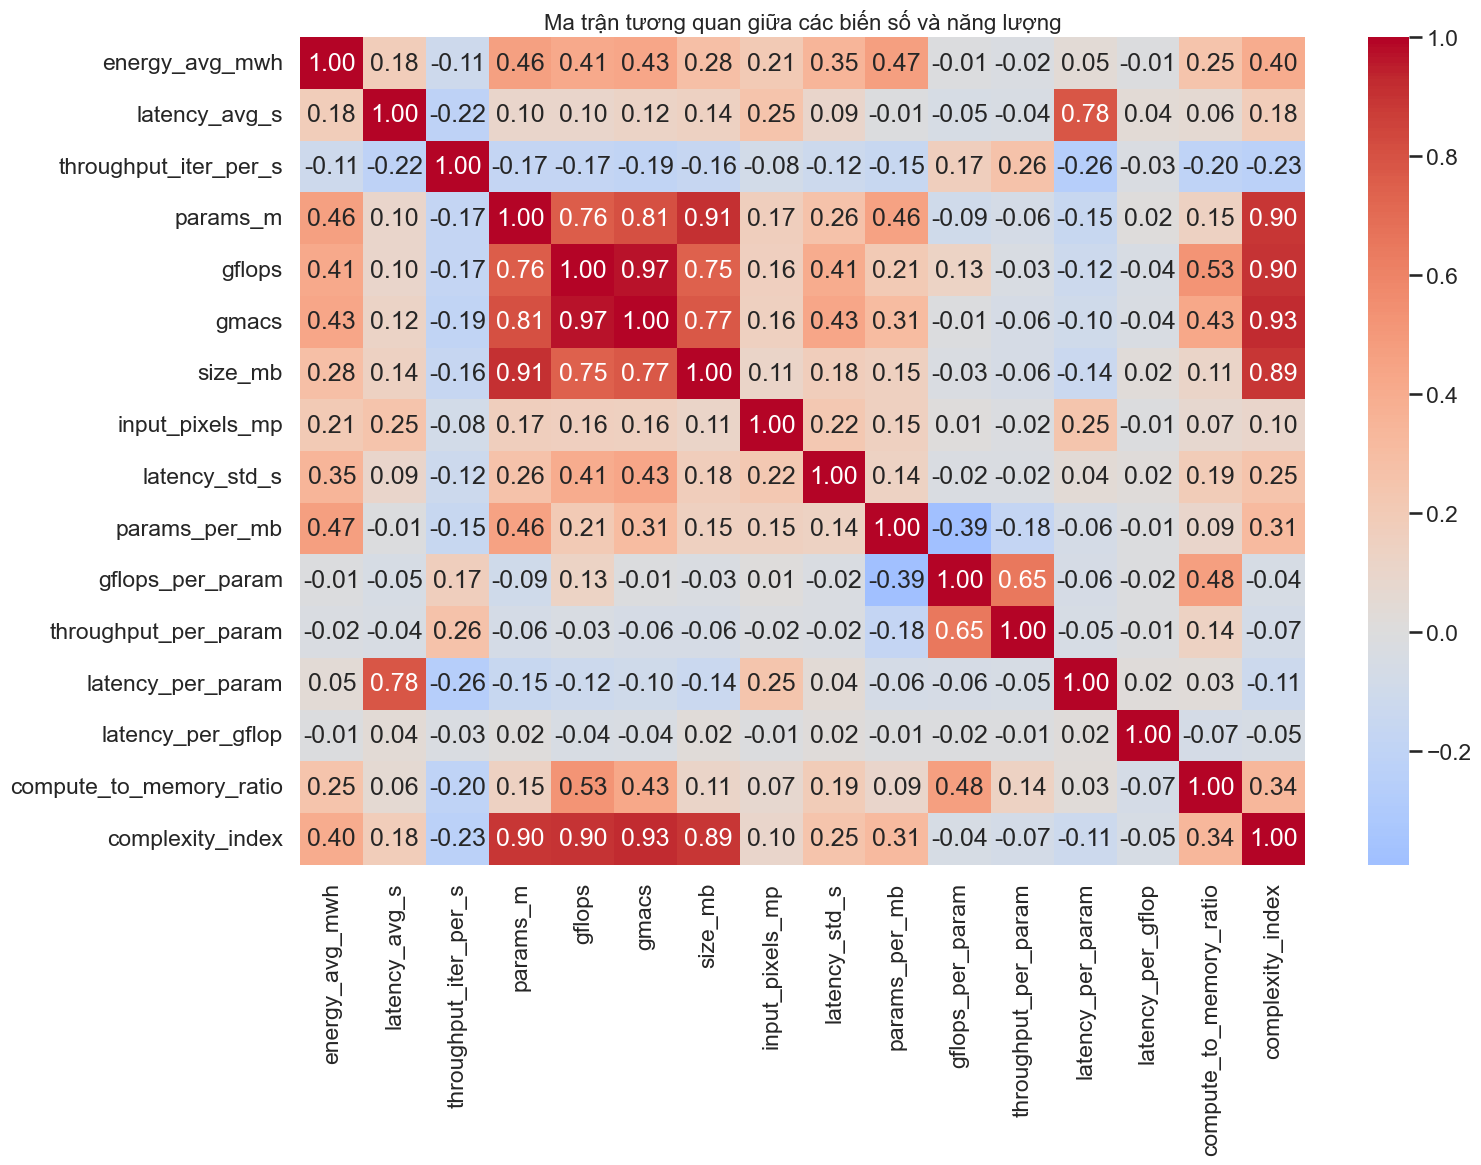

,corr_with_energy
energy_avg_mwh,1.000000
params_per_mb,0.468279
params_m,0.462405
gmacs,0.432081
gflops,0.413934
complexity_index,0.403324
latency_std_s,0.349719
size_mb,0.284041
compute_to_memory_ratio,0.250665
input_pixels_mp,0.206414


In [8]:
correlation_features = [
    "energy_avg_mwh",
    "latency_avg_s",
    "throughput_iter_per_s",
    "params_m",
    "gflops",
    "gmacs",
    "size_mb",
    "input_pixels_mp",
    "latency_std_s",
    "params_per_mb",
    "gflops_per_param",
    "throughput_per_param",
    "latency_per_param",
    "latency_per_gflop",
    "compute_to_memory_ratio",
    "complexity_index",
]
correlation_df = research_df[correlation_features].corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Ma trận tương quan giữa các biến số và năng lượng")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

display(correlation_df["energy_avg_mwh"].sort_values(ascending=False).to_frame("corr_with_energy"))


## 8. Benchmark đa mô hình trên bài toán multi-device unified

Phần này phục vụ nghiên cứu:

- benchmark nhiều mô hình khác nhau,
- thêm GNN để thử biểu diễn dạng đồ thị,
- so sánh trực tiếp trên cùng protocol.

Lưu ý: đây là phần dành cho **phân tích khoa học**, chưa phải phần production final.


In [9]:
split_info = split_dataset(research_df, random_state=SEED)
research_train_df = split_info["train_df"]
research_test_df = split_info["test_df"]

sklearn_results_df, sklearn_artifacts = evaluate_sklearn_models(
    train_df=research_train_df,
    test_df=research_test_df,
    numeric_features=research_numeric_features,
    categorical_features=research_categorical_features,
    feature_columns=research_feature_columns,
    random_state=SEED,
)

gnn_result_row, gnn_artifact = evaluate_gnn_regressor(
    df=research_df,
    train_indices=split_info["train_indices"],
    test_indices=split_info["test_indices"],
    numeric_features=research_numeric_features,
    categorical_features=research_categorical_features,
    feature_columns=research_feature_columns,
    random_state=SEED,
)

new_generation_comparison_df = pd.concat([sklearn_results_df, pd.DataFrame([gnn_result_row])], ignore_index=True)
new_generation_comparison_df = new_generation_comparison_df.sort_values(
    by=["test_rmse", "test_mae", "test_mape_pct"],
    ascending=[True, True, True],
).reset_index(drop=True)

display(new_generation_comparison_df)


,model_name,model_type,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean,test_rmse,test_mae,test_mape_pct,test_smape_pct,test_r2
0,Extra Trees,sklearn,4.552686e+02,3.245841e+02,9.874914e+01,6.379842e-01,192.417459,36.321020,18.922132,18.167428,0.629758
1,Gradient Boosting,sklearn,5.080408e+02,3.962287e+02,1.135142e+02,5.447971e-01,210.685046,47.291393,27.017640,24.984710,0.556121
2,KNN Regressor,sklearn,6.473627e+02,3.096937e+02,1.428954e+02,1.885538e-01,214.462803,48.294655,30.285409,26.093599,0.540060
3,Random Forest,sklearn,5.115714e+02,3.238603e+02,1.153763e+02,5.374027e-01,216.296158,42.301120,24.543520,22.610558,0.532163
4,HistGradient Boosting,sklearn,5.435288e+02,3.583071e+02,1.224891e+02,4.812993e-01,225.583279,53.776698,24.829238,22.000187,0.491126
5,SVR (RBF),sklearn,7.082960e+02,2.237000e+02,1.482925e+02,-1.515234e-01,237.356125,62.210151,30.223280,25.681935,0.436625
6,Similarity Graph Neural Network,gnn,4.618736e+02,2.917804e+02,1.046309e+02,5.235411e-01,243.989881,73.234448,45.949004,35.488921,0.404694
7,MLP Regressor,sklearn,2.024516e+13,2.024238e+13,1.293416e+12,-4.942278e+21,590.738550,126.156803,53.410236,32.621975,-2.489695
8,Ridge Regression,sklearn,1.081404e+08,1.081395e+08,6.908977e+06,-1.410317e+11,600.234527,117.988146,95.603451,44.846041,-2.602789
9,Elastic Net,sklearn,5.410013e+07,5.409916e+07,3.456469e+06,-3.529664e+10,663.173002,123.456096,97.021030,44.738552,-3.397952


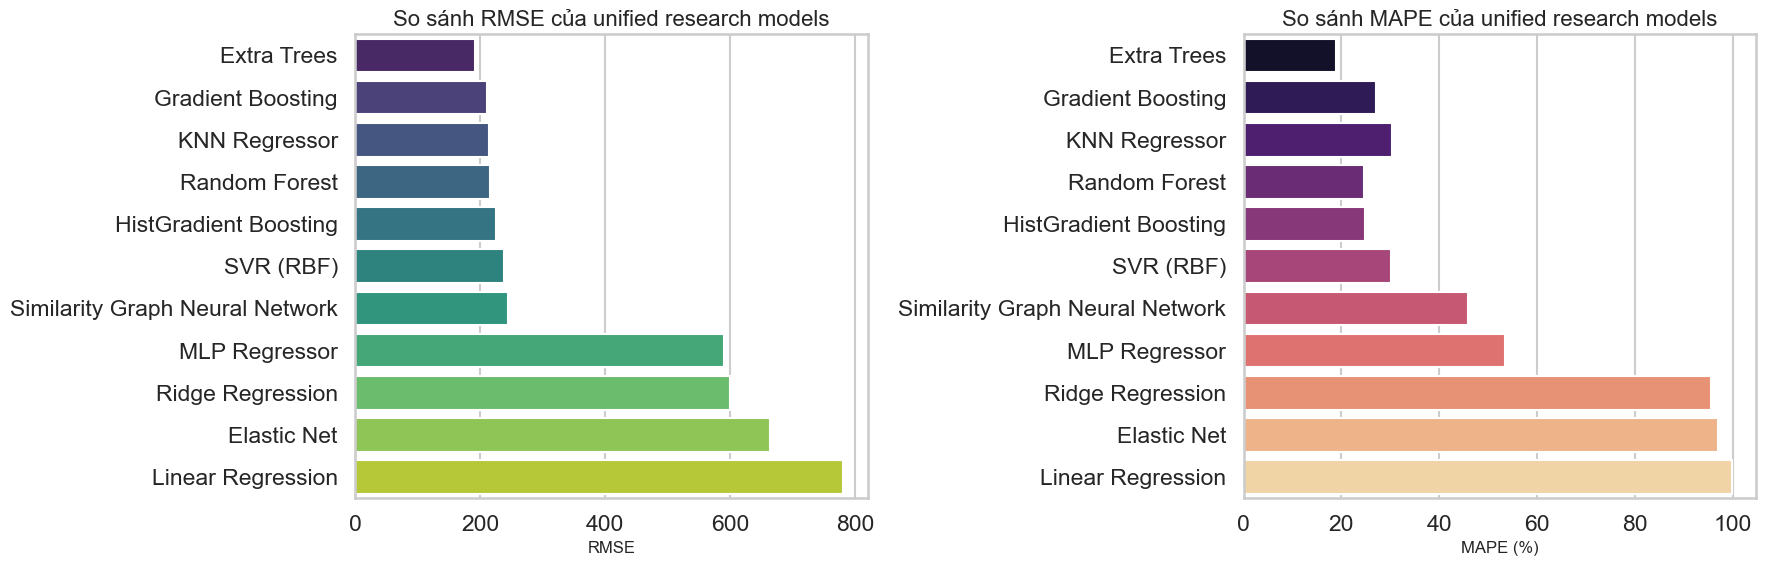

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=new_generation_comparison_df, x="test_rmse", y="model_name", palette="viridis", ax=axes[0])
axes[0].set_title("So sánh RMSE của unified research models")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("")

sns.barplot(data=new_generation_comparison_df, x="test_mape_pct", y="model_name", palette="magma", ax=axes[1])
axes[1].set_title("So sánh MAPE của unified research models")
axes[1].set_xlabel("MAPE (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_unified_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Huấn luyện lại production model tốt nhất từ notebook cũ

Ở đây ta giữ nguyên triết lý cũ:

- **Jetson**: tune theo `RMSE` trên cross-validation phân tầng theo energy bins
- **Raspberry Pi 5**: tune theo `SMAPE`
- mô hình lõi vẫn là **Extra Trees + log1p target**


In [11]:
def build_ttr_pipeline(regressor):
    return Pipeline(
        [
            ("scaler", RobustScaler()),
            (
                "model",
                TransformedTargetRegressor(
                    regressor=regressor,
                    func=np.log1p,
                    inverse_func=np.expm1,
                    check_inverse=False,
                ),
            ),
        ]
    )

SMAPE_SCORER = make_scorer(smape, greater_is_better=False)

def tune_jetson_model(df: pd.DataFrame):
    X = df[FEATURE_COLUMNS_OLD]
    y = df["energy_avg_mwh"].values
    bins = KBinsDiscretizer(
        n_bins=10,
        encode="ordinal",
        strategy="quantile",
        subsample=None,
        quantile_method="averaged_inverted_cdf",
    ).fit_transform(y.reshape(-1, 1)).ravel().astype(int)
    cv = list(StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED).split(X, bins))

    pipeline = build_ttr_pipeline(ExtraTreesRegressor(random_state=SEED, n_jobs=-1))
    param_dist = {
        "model__regressor__n_estimators": randint(800, 1401),
        "model__regressor__max_depth": [12, 16, 20, 24, 28, None],
        "model__regressor__min_samples_split": randint(2, 6),
        "model__regressor__min_samples_leaf": randint(1, 3),
        "model__regressor__max_features": [0.7, 0.8, 0.9, 1.0],
        "model__regressor__bootstrap": [False],
    }

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=35,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X, y)
    pred = cross_val_predict(search.best_estimator_, X, y, cv=cv, n_jobs=1)
    metrics = regression_metrics(y, pred)
    return {
        "device_key": "jetson_nano",
        "best_estimator": search.best_estimator_.fit(X, y),
        "best_params": search.best_params_,
        "cv_metrics": metrics,
        "cv_predictions": pred,
        "samples": int(len(df)),
        "cv_strategy": "StratifiedKFold(n_splits=10)",
    }

def tune_rpi5_model(df: pd.DataFrame):
    X = df[FEATURE_COLUMNS_OLD]
    y = df["energy_avg_mwh"].values
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

    pipeline = build_ttr_pipeline(ExtraTreesRegressor(random_state=SEED, n_jobs=-1))
    param_dist = {
        "model__regressor__n_estimators": randint(900, 1501),
        "model__regressor__max_depth": [8, 10, 12, 14, 16, 18],
        "model__regressor__min_samples_split": randint(2, 5),
        "model__regressor__min_samples_leaf": randint(1, 3),
        "model__regressor__max_features": [0.6, 0.7, 0.8, 0.9],
        "model__regressor__bootstrap": [False],
    }

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=25,
        scoring=SMAPE_SCORER,
        cv=cv,
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X, y)
    pred = cross_val_predict(search.best_estimator_, X, y, cv=cv, n_jobs=1)
    metrics = regression_metrics(y, pred)
    return {
        "device_key": "raspberry_pi5",
        "best_estimator": search.best_estimator_.fit(X, y),
        "best_params": search.best_params_,
        "cv_metrics": metrics,
        "cv_predictions": pred,
        "samples": int(len(df)),
        "cv_strategy": "KFold(n_splits=5)",
    }

legacy_jetson_df = legacy_df[legacy_df["device_type"] == "jetson_nano"].copy()
legacy_rpi5_df = legacy_df[legacy_df["device_type"] == "raspberry_pi5"].copy()

jetson_result = tune_jetson_model(legacy_jetson_df)
rpi5_result = tune_rpi5_model(legacy_rpi5_df)

display(pd.DataFrame([jetson_result["cv_metrics"]]).assign(device="Jetson Nano"))
display(pd.DataFrame([rpi5_result["cv_metrics"]]).assign(device="Raspberry Pi 5"))


,mae,rmse,smape,mape_eps,r2_original,r2_log,median_abs_error,device
0,101.398005,550.342624,20.162175,21.079004,0.614821,0.940213,5.904592,Jetson Nano


,mae,rmse,smape,mape_eps,r2_original,r2_log,median_abs_error,device
0,5.155335,12.075813,12.781385,12.985577,0.889588,0.957145,2.718101,Raspberry Pi 5


## 10. So sánh head-to-head: production cũ vs unified research mới

Đây là phần quan trọng nhất để kết luận:

- liệu notebook mới có vượt notebook cũ ở chất lượng model hay không,
- nên giữ model nào cho production,
- và nên dùng notebook nào cho nghiên cứu.


In [12]:
def fit_old_device_model(train_df: pd.DataFrame, best_params: dict):
    estimator = build_ttr_pipeline(ExtraTreesRegressor(random_state=SEED, n_jobs=-1))
    estimator.set_params(**best_params)
    estimator.fit(train_df[FEATURE_COLUMNS_OLD], train_df["energy_avg_mwh"].values)
    return estimator

legacy_train_df = legacy_df.loc[split_info["train_indices"]].copy()
legacy_test_df = legacy_df.loc[split_info["test_indices"]].copy()

old_jetson_train = legacy_train_df[legacy_train_df["device_type"] == "jetson_nano"].copy()
old_rpi_train = legacy_train_df[legacy_train_df["device_type"] == "raspberry_pi5"].copy()
old_jetson_test = legacy_test_df[legacy_test_df["device_type"] == "jetson_nano"].copy()
old_rpi_test = legacy_test_df[legacy_test_df["device_type"] == "raspberry_pi5"].copy()

old_jetson_model = fit_old_device_model(old_jetson_train, jetson_result["best_params"])
old_rpi_model = fit_old_device_model(old_rpi_train, rpi5_result["best_params"])

old_predictions_df_parts = []
if not old_jetson_test.empty:
    old_jetson_test["prediction_old"] = old_jetson_model.predict(old_jetson_test[FEATURE_COLUMNS_OLD])
    old_predictions_df_parts.append(old_jetson_test)
if not old_rpi_test.empty:
    old_rpi_test["prediction_old"] = old_rpi_model.predict(old_rpi_test[FEATURE_COLUMNS_OLD])
    old_predictions_df_parts.append(old_rpi_test)
old_predictions_df = pd.concat(old_predictions_df_parts).sort_index()

best_new_model_name, best_new_artifact = choose_best_model(
    comparison_df=new_generation_comparison_df,
    sklearn_artifacts=sklearn_artifacts,
    gnn_artifact=gnn_artifact,
)
new_predictions_df = research_df.loc[best_new_artifact["test_index"]].copy()
new_predictions_df["prediction_new"] = best_new_artifact["test_predictions"]
new_predictions_df = new_predictions_df.sort_index()

overall_comparison_df = pd.DataFrame(
    [
        {"approach": "old_device_specific_extra_trees", **compute_metrics(old_predictions_df["energy_avg_mwh"], old_predictions_df["prediction_old"])},
        {"approach": f"new_multidevice_{best_new_model_name.lower().replace(' ', '_')}", **best_new_artifact["metrics"]},
    ]
)

by_device_rows = []
for device_name, group_df in old_predictions_df.groupby("device_name"):
    by_device_rows.append(
        {
            "approach": "old_device_specific_extra_trees",
            "device_name": device_name,
            **compute_metrics(group_df["energy_avg_mwh"], group_df["prediction_old"]),
        }
    )
for device_name, group_df in new_predictions_df.groupby("device_name"):
    by_device_rows.append(
        {
            "approach": f"new_multidevice_{best_new_model_name.lower().replace(' ', '_')}",
            "device_name": device_name,
            **compute_metrics(group_df["energy_avg_mwh"], group_df["prediction_new"]),
        }
    )
by_device_comparison_df = pd.DataFrame(by_device_rows)

display(overall_comparison_df.sort_values("rmse"))
display(by_device_comparison_df.sort_values(["device_name", "rmse"]))


,approach,rmse,mae,mape_pct,smape_pct,r2
0,old_device_specific_extra_trees,142.655567,32.788445,16.717777,15.886853,0.796495
1,new_multidevice_extra_trees,192.417459,36.321020,18.922132,18.167428,0.629758


,approach,device_name,rmse,mae,mape_pct,smape_pct,r2
0,old_device_specific_extra_trees,Jetson Nano,185.691152,51.290698,20.169848,18.371200,0.778299
2,new_multidevice_extra_trees,Jetson Nano,251.119470,57.381121,22.912070,21.581167,0.594542
3,new_multidevice_extra_trees,Raspberry Pi 5,16.341745,6.589112,13.289279,13.348032,0.832738
1,old_device_specific_extra_trees,Raspberry Pi 5,20.038424,6.667616,11.844264,12.379540,0.748505


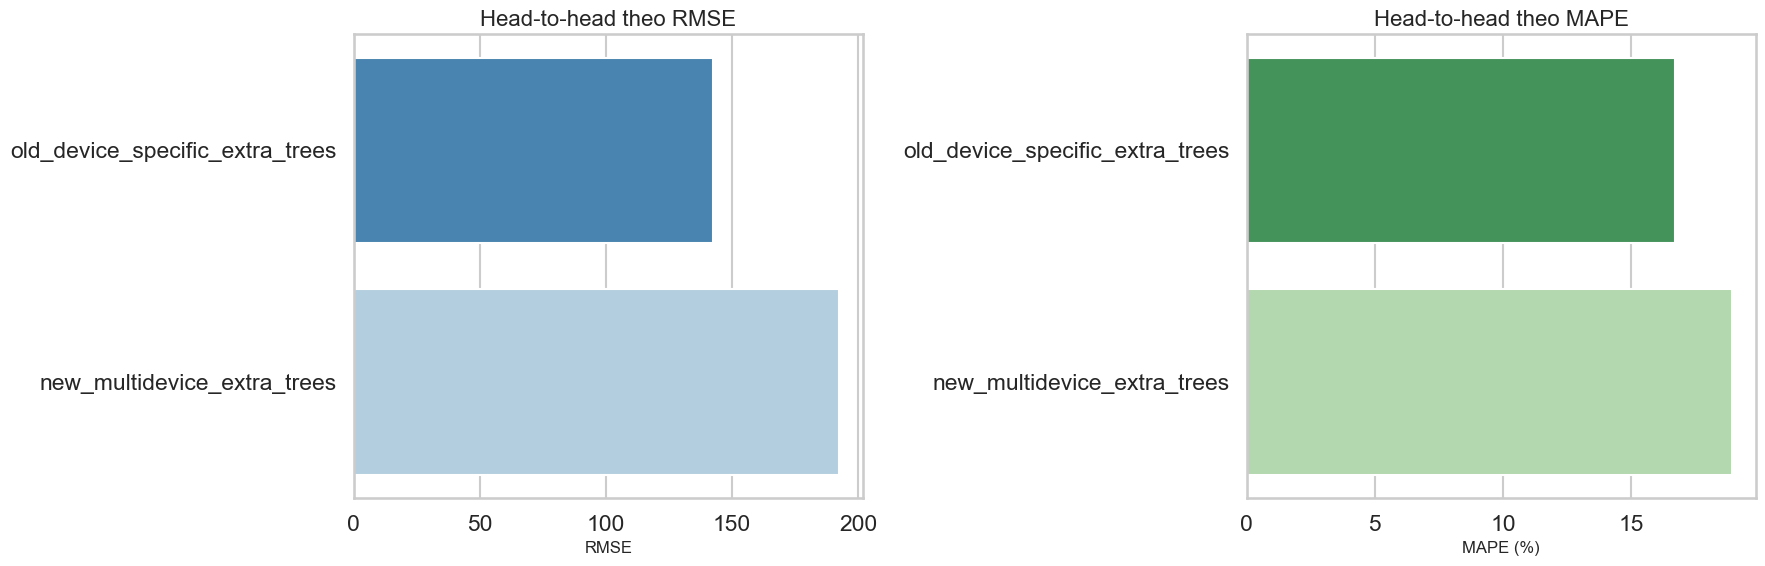

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=overall_comparison_df, x="rmse", y="approach", palette="Blues_r", ax=axes[0])
axes[0].set_title("Head-to-head theo RMSE")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("")

sns.barplot(data=overall_comparison_df, x="mape_pct", y="approach", palette="Greens_r", ax=axes[1])
axes[1].set_title("Head-to-head theo MAPE")
axes[1].set_xlabel("MAPE (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_old_vs_new_head_to_head.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Phân tích chi tiết production winner

Nếu model production cũ vẫn thắng, ta phân tích sâu trên từng thiết bị:

- actual vs predicted,
- residual distribution,
- đặc trưng `batch_high_power` trên Jetson,
- và các điểm khó dự đoán nhất.


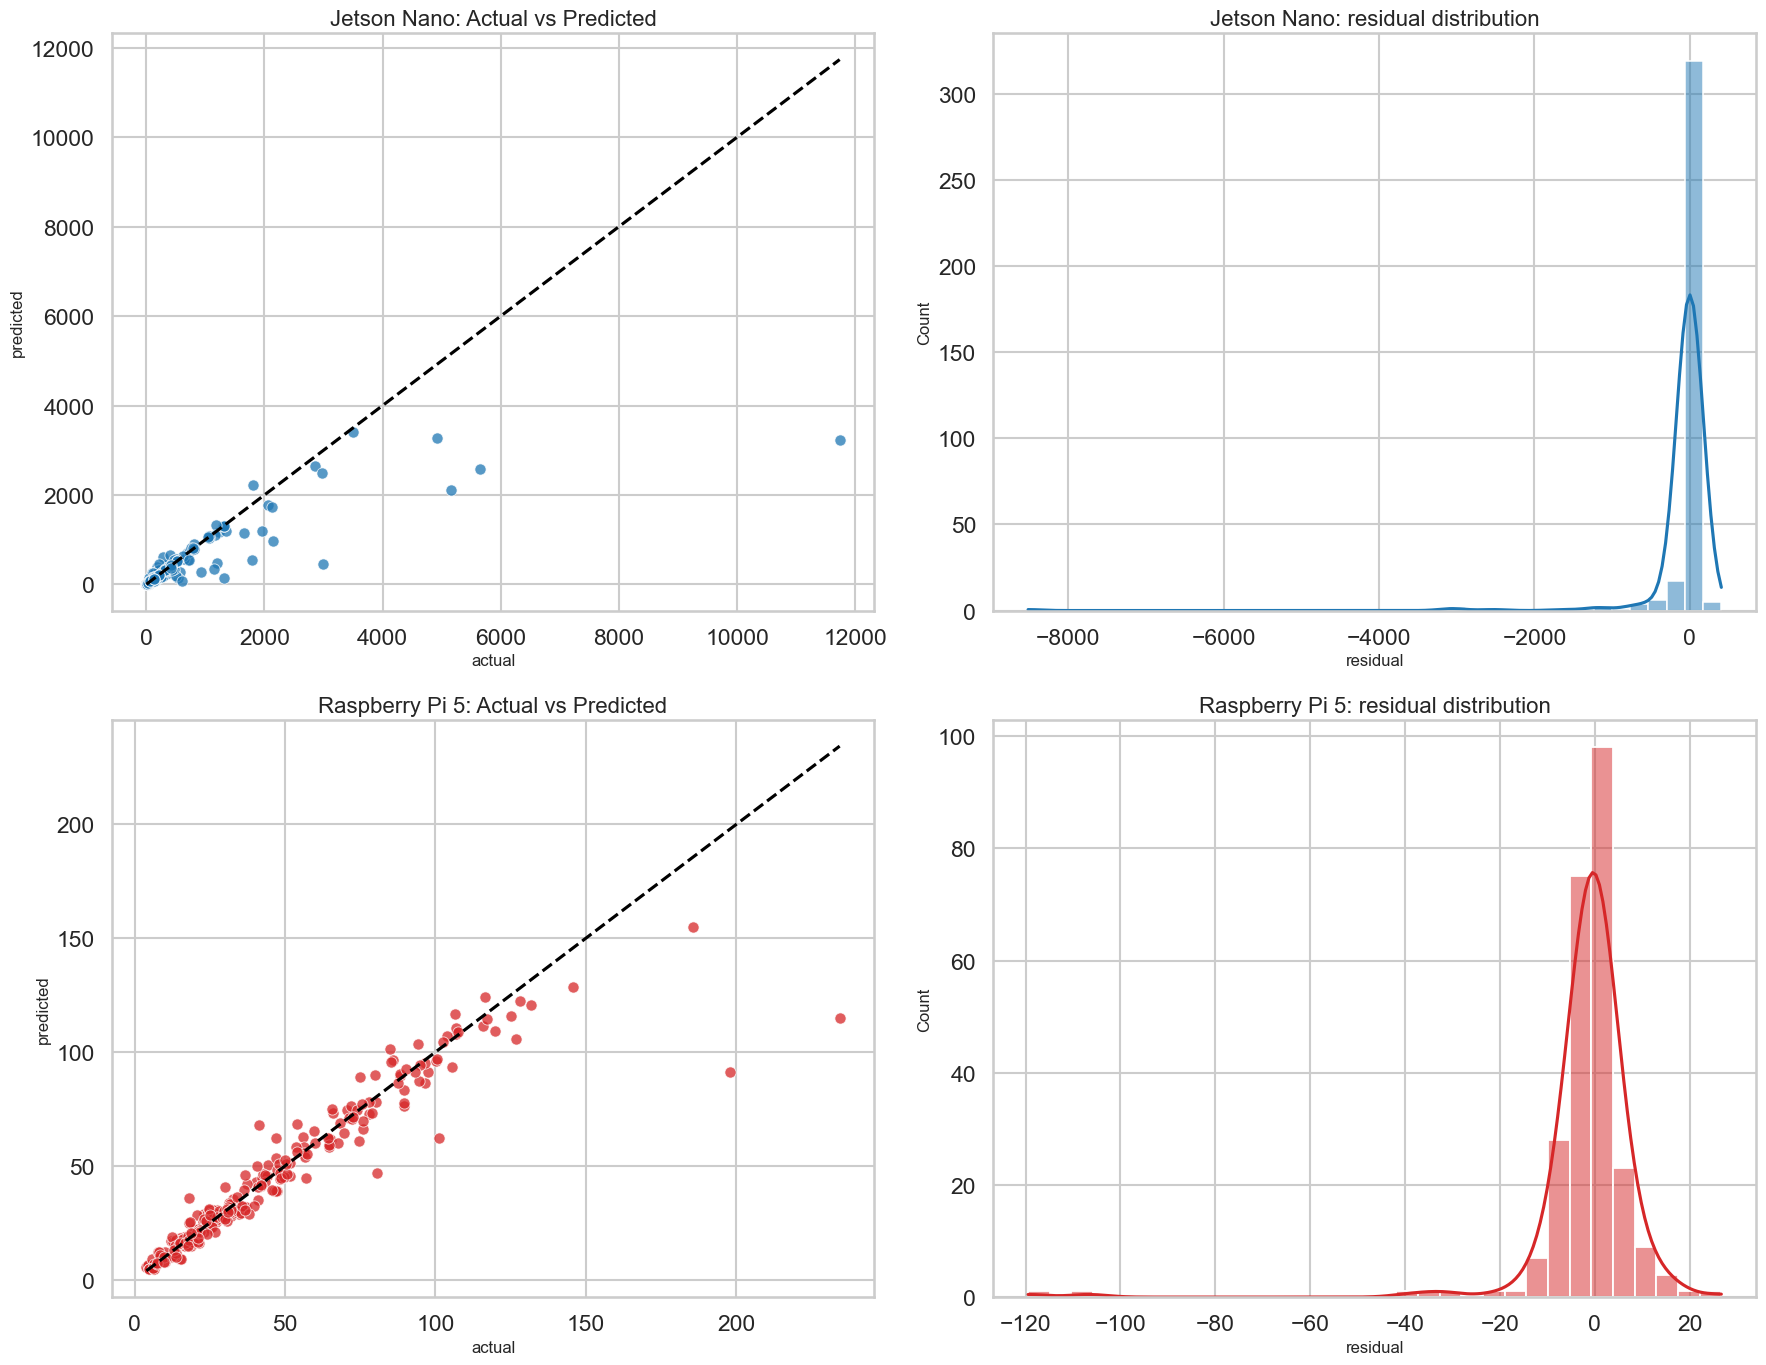

,actual,predicted,residual,abs_pct_error
count,360.0000,360.0000,360.0000,360.0000
mean,324.1472,248.1062,-76.0410,21.0790
std,887.9852,473.2420,545.8226,32.1582
min,2.3914,4.0845,-8516.1875,0.0002
25%,29.9900,28.3217,-7.3861,2.6104
50%,98.6067,99.5748,-0.1457,9.5886
75%,226.5200,231.3957,4.8790,25.5836
max,11736.4090,3407.0791,405.1444,274.2243


,actual,predicted,residual,abs_pct_error
count,253.0000,253.0000,253.0000,253.0000
mean,44.5617,43.0634,-1.4984,12.9856
std,36.4139,32.0231,12.0062,13.1853
min,3.8361,4.5659,-119.4584,0.0525
25%,17.9912,17.4659,-3.3376,4.0163
50%,31.9855,30.6979,-0.3958,9.6558
75%,64.8082,62.0246,2.2833,16.7359
max,234.4409,154.8288,26.6957,98.0896


In [14]:
jetson_diag = pd.DataFrame({
    "actual": legacy_jetson_df["energy_avg_mwh"].values,
    "predicted": jetson_result["cv_predictions"],
})
jetson_diag["residual"] = jetson_diag["predicted"] - jetson_diag["actual"]
jetson_diag["abs_pct_error"] = np.abs(jetson_diag["residual"]) / np.maximum(np.abs(jetson_diag["actual"]), 1e-9) * 100.0

rpi5_diag = pd.DataFrame({
    "actual": legacy_rpi5_df["energy_avg_mwh"].values,
    "predicted": rpi5_result["cv_predictions"],
})
rpi5_diag["residual"] = rpi5_diag["predicted"] - rpi5_diag["actual"]
rpi5_diag["abs_pct_error"] = np.abs(rpi5_diag["residual"]) / np.maximum(np.abs(rpi5_diag["actual"]), 1e-9) * 100.0

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.scatterplot(data=jetson_diag, x="actual", y="predicted", alpha=0.75, s=65, color="#1f77b4", ax=axes[0, 0])
min_v = min(jetson_diag["actual"].min(), jetson_diag["predicted"].min())
max_v = max(jetson_diag["actual"].max(), jetson_diag["predicted"].max())
axes[0, 0].plot([min_v, max_v], [min_v, max_v], linestyle="--", color="black")
axes[0, 0].set_title("Jetson Nano: Actual vs Predicted")

sns.histplot(jetson_diag["residual"], kde=True, color="#1f77b4", ax=axes[0, 1])
axes[0, 1].set_title("Jetson Nano: residual distribution")

sns.scatterplot(data=rpi5_diag, x="actual", y="predicted", alpha=0.75, s=65, color="#d62728", ax=axes[1, 0])
min_v = min(rpi5_diag["actual"].min(), rpi5_diag["predicted"].min())
max_v = max(rpi5_diag["actual"].max(), rpi5_diag["predicted"].max())
axes[1, 0].plot([min_v, max_v], [min_v, max_v], linestyle="--", color="black")
axes[1, 0].set_title("Raspberry Pi 5: Actual vs Predicted")

sns.histplot(rpi5_diag["residual"], kde=True, color="#d62728", ax=axes[1, 1])
axes[1, 1].set_title("Raspberry Pi 5: residual distribution")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_production_model_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

display(jetson_diag.describe().round(4))
display(rpi5_diag.describe().round(4))


## 12. Feature importance cho research winner

Mặc dù production winner hiện là device-specific Extra Trees, notebook vẫn phân tích feature importance cho research winner để hỗ trợ diễn giải khoa học và hướng cải tiến tiếp theo.


,feature_name,rmse_delta_mean,rmse_delta_std
0,params_per_mb,146.516225,127.166200
1,device_family,32.423740,10.550030
2,device_type,25.382248,12.876768
3,complexity_index,21.564431,11.101562
4,params_m,20.237026,3.725850
5,gmacs,15.309372,1.977428
6,is_mobile_optimized,15.081517,6.261735
7,throughput_iter_per_s,12.784284,5.262264
8,gflops,9.536881,4.553088
9,throughput_per_param,9.032171,4.181727


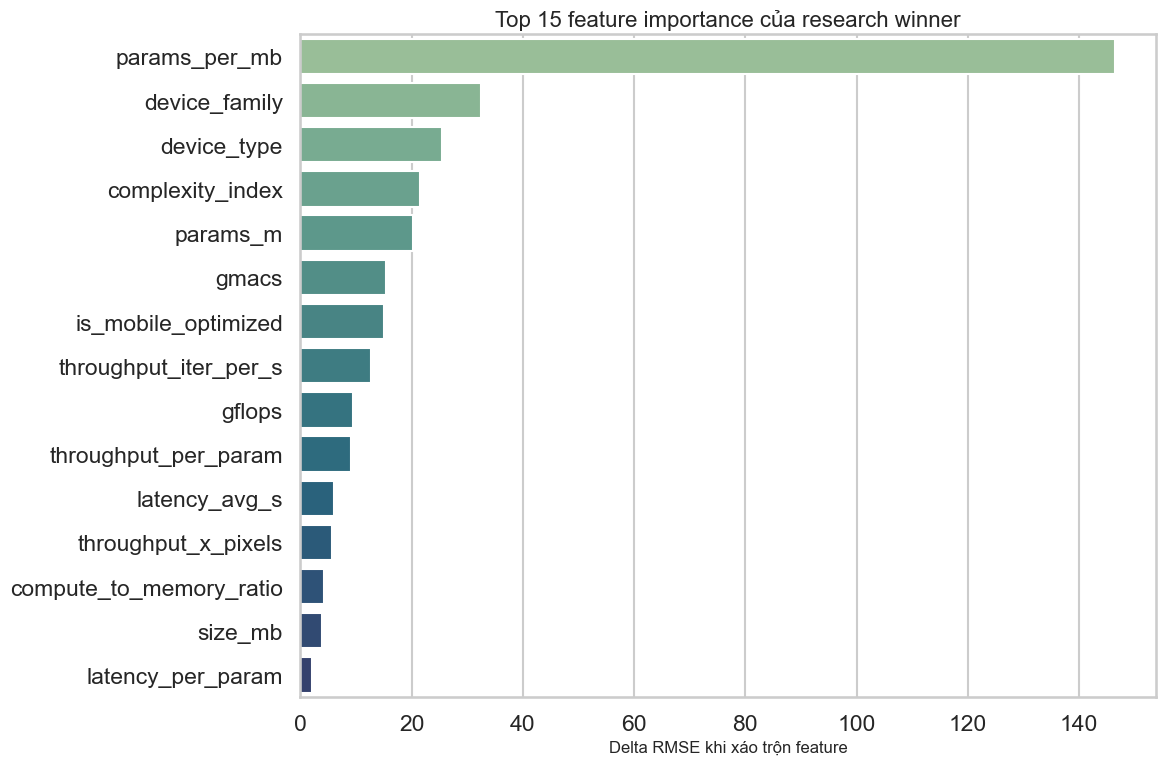

In [15]:
research_test_subset = research_df.loc[best_new_artifact["test_index"]].copy()
research_test_subset["prediction"] = best_new_artifact["test_predictions"]

importance_df = compute_artifact_permutation_importance(
    artifact=best_new_artifact,
    frame=research_test_subset,
    target_col="energy_avg_mwh",
    feature_columns=research_feature_columns,
    n_repeats=6,
    random_state=SEED,
)

display(importance_df.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(15), x="rmse_delta_mean", y="feature_name", palette="crest")
plt.title("Top 15 feature importance của research winner")
plt.xlabel("Delta RMSE khi xáo trộn feature")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_research_winner_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Lưu artifact cuối cùng

Notebook này lưu ra hai nhóm artifact:

1. **Production artifacts**:
   - `jetson_energy_model.pkl`
   - `rpi5_energy_model.pkl`
   - `energy_predictor.pkl` fallback
   - metadata / thresholds / feature names
2. **Research artifacts**:
   - bảng so sánh model,
   - bảng head-to-head old vs new,
   - figure cho báo cáo.


In [16]:
def train_unified_fallback(df: pd.DataFrame):
    X = df[FEATURE_COLUMNS_OLD]
    y = df["energy_avg_mwh"].values
    scaler = RobustScaler().fit(X)
    model = ExtraTreesRegressor(
        n_estimators=900,
        max_depth=18,
        max_features=0.9,
        min_samples_split=2,
        min_samples_leaf=1,
        bootstrap=False,
        random_state=SEED,
        n_jobs=-1,
    )
    model.fit(scaler.transform(X), y)
    pred = model.predict(scaler.transform(X))
    return {
        "model": model,
        "scaler": scaler,
        "train_metrics": regression_metrics(y, pred),
        "samples": int(len(df)),
    }

fallback_result = train_unified_fallback(legacy_df)
jetson_scaler = RobustScaler().fit(legacy_jetson_df[FEATURE_COLUMNS_OLD])
rpi5_scaler = RobustScaler().fit(legacy_rpi5_df[FEATURE_COLUMNS_OLD])

jetson_energy = legacy_jetson_df["energy_avg_mwh"].values
rpi5_energy = legacy_rpi5_df["energy_avg_mwh"].values

thresholds = {
    "jetson_nano": {
        "p10": float(np.percentile(jetson_energy, 10)),
        "p25": float(np.percentile(jetson_energy, 25)),
        "p50": float(np.percentile(jetson_energy, 50)),
        "p75": float(np.percentile(jetson_energy, 75)),
        "p90": float(np.percentile(jetson_energy, 90)),
        "recommended_threshold": float(np.percentile(jetson_energy, 25)),
        "unit": "mWh",
        "interpretation": "Mô hình dưới P25 thuộc top 25% tiết kiệm năng lượng nhất",
    },
    "raspberry_pi5": {
        "p10": float(np.percentile(rpi5_energy, 10)),
        "p25": float(np.percentile(rpi5_energy, 25)),
        "p50": float(np.percentile(rpi5_energy, 50)),
        "p75": float(np.percentile(rpi5_energy, 75)),
        "p90": float(np.percentile(rpi5_energy, 90)),
        "recommended_threshold": float(np.percentile(rpi5_energy, 25)),
        "unit": "mWh",
        "interpretation": "Mô hình dưới P25 thuộc top 25% tiết kiệm năng lượng nhất",
    },
    "methodology": "Percentile tính từ benchmark thực tế theo từng thiết bị",
    "last_updated": datetime.now(timezone.utc).isoformat(),
}

metadata = {
    "training_date": datetime.now(timezone.utc).isoformat(),
    "approach": "energy_prediction_master_notebook",
    "production_winner": "device_specific_extra_trees_v2",
    "research_winner": best_new_model_name,
    "random_seed": SEED,
    "legacy_feature_count": len(FEATURE_COLUMNS_OLD),
    "legacy_feature_columns": FEATURE_COLUMNS_OLD,
    "research_feature_count": len(research_feature_columns),
    "research_feature_columns": research_feature_columns,
    "jetson_batch_threshold_mwh_per_s": JETSON_BATCH_THRESHOLD,
    "jetson_model": {
        "model_type": type(jetson_result["best_estimator"]).__name__,
        "model_name": "Extra Trees + log1p target",
        "n_samples_total": jetson_result["samples"],
        "features": FEATURE_COLUMNS_OLD,
        "metrics": {
            "cv_smape": jetson_result["cv_metrics"]["smape"],
            "cv_mape_eps": jetson_result["cv_metrics"]["mape_eps"],
            "cv_r2": jetson_result["cv_metrics"]["r2_log"],
            "cv_r2_original": jetson_result["cv_metrics"]["r2_original"],
            "cv_mae": jetson_result["cv_metrics"]["mae"],
            "cv_rmse": jetson_result["cv_metrics"]["rmse"],
            "cv_median_abs_error": jetson_result["cv_metrics"]["median_abs_error"],
        },
        "cv_strategy": jetson_result["cv_strategy"],
        "best_params": {k: (v.item() if hasattr(v, "item") else v) for k, v in jetson_result["best_params"].items()},
    },
    "rpi5_model": {
        "model_type": type(rpi5_result["best_estimator"]).__name__,
        "model_name": "Extra Trees + log1p target",
        "n_samples_total": rpi5_result["samples"],
        "features": FEATURE_COLUMNS_OLD,
        "metrics": {
            "cv_smape": rpi5_result["cv_metrics"]["smape"],
            "cv_mape_eps": rpi5_result["cv_metrics"]["mape_eps"],
            "cv_r2": rpi5_result["cv_metrics"]["r2_log"],
            "cv_r2_original": rpi5_result["cv_metrics"]["r2_original"],
            "cv_mae": rpi5_result["cv_metrics"]["mae"],
            "cv_rmse": rpi5_result["cv_metrics"]["rmse"],
            "cv_median_abs_error": rpi5_result["cv_metrics"]["median_abs_error"],
        },
        "cv_strategy": rpi5_result["cv_strategy"],
        "best_params": {k: (v.item() if hasattr(v, "item") else v) for k, v in rpi5_result["best_params"].items()},
    },
    "fallback_unified_model": {
        "model_type": type(fallback_result["model"]).__name__,
        "model_name": "Extra Trees fallback (no target log transform)",
        "n_samples_total": fallback_result["samples"],
        "features": FEATURE_COLUMNS_OLD,
        "train_metrics": fallback_result["train_metrics"],
    },
    "overall_head_to_head": overall_comparison_df.to_dict(orient="records"),
}

artifacts = {
    ARTIFACTS_DIR / "jetson_energy_model.pkl": jetson_result["best_estimator"],
    ARTIFACTS_DIR / "jetson_scaler.pkl": jetson_scaler,
    ARTIFACTS_DIR / "rpi5_energy_model.pkl": rpi5_result["best_estimator"],
    ARTIFACTS_DIR / "rpi5_scaler.pkl": rpi5_scaler,
    ARTIFACTS_DIR / "energy_predictor.pkl": fallback_result["model"],
    ARTIFACTS_DIR / "energy_scaler.pkl": fallback_result["scaler"],
}

for path, obj in artifacts.items():
    with open(path, "wb") as handle:
        pickle.dump(obj, handle)

with open(ARTIFACTS_DIR / "feature_names.pkl", "wb") as handle:
    pickle.dump(FEATURE_COLUMNS_OLD, handle)

with open(ARTIFACTS_DIR / "device_specific_features.json", "w", encoding="utf-8") as handle:
    json.dump(FEATURE_COLUMNS_OLD, handle, indent=2, ensure_ascii=False)

with open(ARTIFACTS_DIR / "device_specific_metadata.json", "w", encoding="utf-8") as handle:
    json.dump(metadata, handle, indent=2, ensure_ascii=False)

with open(ARTIFACTS_DIR / "energy_thresholds.json", "w", encoding="utf-8") as handle:
    json.dump(thresholds, handle, indent=2, ensure_ascii=False)

overall_comparison_df.to_csv(ARTIFACTS_DIR / "energy_prediction_generation_comparison_overall.csv", index=False)
by_device_comparison_df.to_csv(ARTIFACTS_DIR / "energy_prediction_generation_comparison_by_device.csv", index=False)
new_generation_comparison_df.to_csv(ARTIFACTS_DIR / "energy_prediction_generation_new_leaderboard.csv", index=False)
importance_df.to_csv(ARTIFACTS_DIR / "energy_prediction_complete_feature_importance.csv", index=False)

save_info = save_best_model(
    model_name=best_new_model_name,
    artifact=best_new_artifact,
    output_dir=ARTIFACTS_DIR,
    comparison_df=new_generation_comparison_df,
)

display(pd.DataFrame([save_info]))
print("Artifacts exported to:", ARTIFACTS_DIR)


,model_path,metadata_path,comparison_path
0,D:\KLTN\DACN_Energy_consumption\ml-controller\...,D:\KLTN\DACN_Energy_consumption\ml-controller\...,D:\KLTN\DACN_Energy_consumption\ml-controller\...


Artifacts exported to: D:\KLTN\DACN_Energy_consumption\ml-controller\artifacts


In [17]:
figure_files = sorted(path.name for path in FIGURE_DIR.glob("*.png"))

print("=" * 110)
print("MASTER NOTEBOOK SUMMARY")
print("=" * 110)
print("Production winner : device_specific_extra_trees_v2")
print("Research winner   :", best_new_model_name)
print("\nOverall comparison:")
display(overall_comparison_df.sort_values("rmse").round(4))
print("\nBy-device comparison:")
display(by_device_comparison_df.sort_values(["device_name", "rmse"]).round(4))
print("\nGenerated figures:")
for file_name in figure_files:
    print("-", file_name)


MASTER NOTEBOOK SUMMARY
Production winner : device_specific_extra_trees_v2
Research winner   : Extra Trees

Overall comparison:


,approach,rmse,mae,mape_pct,smape_pct,r2
0,old_device_specific_extra_trees,142.6556,32.7884,16.7178,15.8869,0.7965
1,new_multidevice_extra_trees,192.4175,36.3210,18.9221,18.1674,0.6298



By-device comparison:


,approach,device_name,rmse,mae,mape_pct,smape_pct,r2
0,old_device_specific_extra_trees,Jetson Nano,185.6912,51.2907,20.1698,18.3712,0.7783
2,new_multidevice_extra_trees,Jetson Nano,251.1195,57.3811,22.9121,21.5812,0.5945
3,new_multidevice_extra_trees,Raspberry Pi 5,16.3417,6.5891,13.2893,13.3480,0.8327
1,old_device_specific_extra_trees,Raspberry Pi 5,20.0384,6.6676,11.8443,12.3795,0.7485



Generated figures:
- 01_distribution_by_device.png
- 02_family_function_distribution.png
- 03_energy_relationships.png
- 04_correlation_matrix.png
- 05_unified_model_comparison.png
- 06_old_vs_new_head_to_head.png
- 07_production_model_diagnostics.png
- 08_research_winner_feature_importance.png
